# 03 — Imbalanced Data: So sánh SMOTE / Undersampling / Class Weight

Mục tiêu: quyết định chiến lược xử lý imbalance nào dùng cho Giai đoạn 3
(train 4 model chính thức). Dùng Logistic Regression làm model "thăm dò"
nhanh (không phải model cuối) để so sánh 4 chiến lược trên cùng 1 test set
cố định, không đổi.

**Nguyên tắc bắt buộc:** resampling (SMOTE/undersampling) CHỈ áp dụng lên
tập train. Test set giữ nguyên phân phối thật (0.17% fraud) để đánh giá
đúng thực tế — nếu resample cả test, số liệu đánh giá sẽ ảo, không phản ánh
được model hoạt động thế nào khi triển khai thật.

In [1]:
!pip install -q imbalanced-learn

In [2]:
import kagglehub
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print(f"Shape: {df.shape}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (284807, 31)


## 1. Clean + Split + Feature Engineering
(giống hệt logic trong `src/data/preprocessing.py` và
`src/features/feature_engineering.py` — copy vào đây để notebook chạy
độc lập trên Colab, không cần upload file .py riêng)

In [3]:
# --- Clean + split (giống preprocessing.py) ---
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["Class"]
)
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

print(f"Train: {len(train_df)} | fraud rate: {train_df['Class'].mean()*100:.4f}%")
print(f"Test:  {len(test_df)} | fraud rate: {test_df['Class'].mean()*100:.4f}%")

Train: 227127 | fraud rate: 0.1686%
Test:  56892 | fraud rate: 0.1705%


In [4]:
# --- Feature engineering (giống feature_engineering.py) ---
FEATURE_COLUMNS = [f"V{i}" for i in range(1, 29)] + ["Amount_log", "Time_hour"]

def engineer_features(d):
    d = d.copy()
    d["Amount_log"] = np.log1p(d["Amount"])
    d["Time_hour"] = (d["Time"] % 86400) / 3600
    return d

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLUMNS])   # fit CHỈ trên train
y_train = train_df["Class"].values

X_test = scaler.transform(test_df[FEATURE_COLUMNS])          # transform, KHÔNG fit lại
y_test = test_df["Class"].values

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Fraud trong y_train: {y_train.sum()} | Fraud trong y_test: {y_test.sum()}")

X_train: (227127, 30), X_test: (56892, 30)
Fraud trong y_train: 383 | Fraud trong y_test: 97


## 2. Hàm đánh giá chung
Dùng lại cho cả 4 chiến lược để đảm bảo so sánh công bằng — cùng test set,
cùng ngưỡng threshold mặc định 0.5, cùng bộ metric.

In [5]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        "strategy": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "pr_auc": average_precision_score(y_test, y_proba),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    return result

results = []

## 3. Chiến lược A — Baseline (không xử lý gì)

In [6]:
model_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_baseline.fit(X_train, y_train)
results.append(evaluate(model_baseline, X_test, y_test, "Baseline (no resampling)"))
print(results[-1])

{'strategy': 'Baseline (no resampling)', 'precision': 0.8289473684210527, 'recall': 0.6494845360824743, 'f1': 0.7283236994219653, 'pr_auc': np.float64(0.7330300253317916), 'roc_auc': np.float64(0.9584283501070497)}


## 4. Chiến lược B — Class Weight
Không sinh/xóa dữ liệu, chỉ tăng "trọng số phạt" khi model đoán sai lớp fraud.
Rẻ nhất về mặt tính toán, không tốn thêm bộ nhớ.

In [7]:
model_cw = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
model_cw.fit(X_train, y_train)
results.append(evaluate(model_cw, X_test, y_test, "Class Weight (balanced)"))
print(results[-1])

{'strategy': 'Class Weight (balanced)', 'precision': 0.05285285285285285, 'recall': 0.9072164948453608, 'f1': 0.09988649262202043, 'pr_auc': np.float64(0.7096954444848719), 'roc_auc': np.float64(0.9707437582987467)}


## 5. Chiến lược C — Random Under Sampling
Giảm số lượng mẫu Legit trong train xuống bằng số lượng Fraud. Rủi ro:
vứt bỏ rất nhiều thông tin (train gốc ~227k dòng, sau undersample chỉ còn
vài trăm dòng mỗi lớp) — dễ underfit.

In [8]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"Sau undersampling: {X_train_rus.shape}, fraud: {y_train_rus.sum()}, legit: {(y_train_rus==0).sum()}")

model_rus = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_rus.fit(X_train_rus, y_train_rus)
results.append(evaluate(model_rus, X_test, y_test, "Random Undersampling"))
print(results[-1])

Sau undersampling: (766, 30), fraud: 383, legit: 383
{'strategy': 'Random Undersampling', 'precision': 0.04557224236147074, 'recall': 0.9072164948453608, 'f1': 0.08678500986193294, 'pr_auc': np.float64(0.6527950892705894), 'roc_auc': np.float64(0.9701300481111759)}


## 6. Chiến lược D — SMOTE
Sinh thêm mẫu Fraud tổng hợp (nội suy giữa các mẫu fraud thật gần nhau) thay
vì bỏ bớt Legit. Giữ được toàn bộ thông tin của Legit, nhưng tốn thời gian
train hơn và có rủi ro sinh mẫu tổng hợp không thực tế nếu fraud gốc quá ít
và phân tán.

In [9]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Sau SMOTE: {X_train_smote.shape}, fraud: {y_train_smote.sum()}, legit: {(y_train_smote==0).sum()}")

model_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_smote.fit(X_train_smote, y_train_smote)
results.append(evaluate(model_smote, X_test, y_test, "SMOTE"))
print(results[-1])

Sau SMOTE: (453488, 30), fraud: 226744, legit: 226744
{'strategy': 'SMOTE', 'precision': 0.053229665071770335, 'recall': 0.9175257731958762, 'f1': 0.10062182023742228, 'pr_auc': np.float64(0.7227544072034994), 'roc_auc': np.float64(0.9699468970969021)}


## 7. So sánh kết quả

In [11]:
results_df = pd.DataFrame(results).set_index("strategy")
results_df = results_df.sort_values("pr_auc", ascending=False)
results_df.round(4)

,precision,recall,f1,pr_auc,roc_auc
strategy,,,,,
Baseline (no resampling),0.8289,0.6495,0.7283,0.7330,0.9584
SMOTE,0.0532,0.9175,0.1006,0.7228,0.9699
Class Weight (balanced),0.0529,0.9072,0.0999,0.7097,0.9707
Random Undersampling,0.0456,0.9072,0.0868,0.6528,0.9701


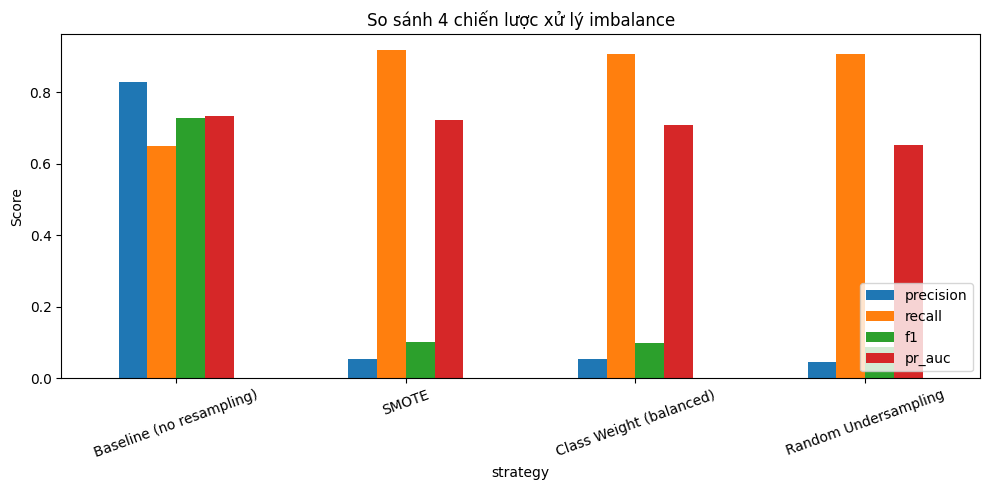

In [12]:
results_df[["precision", "recall", "f1", "pr_auc"]].plot(kind="bar", figsize=(10, 5))
plt_title = "So sánh 4 chiến lược xử lý imbalance"
import matplotlib.pyplot as plt
plt.title(plt_title)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Kết luận (điền lại sau khi chạy với số liệu thật)

Cách đọc bảng so sánh:
- **PR-AUC** là chỉ số tin cậy nhất để so sánh (đã giải thích ở business_understanding.md)
  vì không bị ảnh hưởng bởi việc chọn threshold 0.5 mặc định.
- Nếu **Recall** của Class Weight/SMOTE cao hơn hẳn Baseline nhưng **Precision** giảm
  → đúng như kỳ vọng lý thuyết: xử lý imbalance thường đánh đổi bắt được nhiều fraud
  hơn (recall tăng) để đổi lấy nhiều false positive hơn (precision giảm).
- Nếu Random Undersampling cho kết quả tệ hơn hẳn 2 cái kia → xác nhận giả thuyết
  "vứt quá nhiều thông tin train" đã nêu ở trên.

Chiến lược được chọn cho Giai đoạn 3 (train 4 model chính thức): **điền sau khi xem bảng**

Lưu ý khi qua Giai đoạn 3: chỉ chọn 1 chiến lược duy nhất áp dụng thống nhất cho cả
4 model (Logistic Regression, Decision Tree, Random Forest, XGBoost), trừ khi có
lý do cụ thể để mỗi model dùng cách khác nhau (ví dụ: Random Forest/XGBoost có thể
dùng trực tiếp `scale_pos_weight`/`class_weight` riêng thay vì resampling).